# Task 3 — Evaluation, Stability & Cluster Interpretation

**Team:** Luís Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Sub-tasks covered:**
- **Task 3.1** — Internal validity comparison (Silhouette, Calinski–Harabász, Davies–Bouldin)
- **Task 3.3** — Stability & sensitivity (5 seeds · RobustScaler variant · cross-method ARI)
- **Task 3.4** — Cluster interpretation, profiles, and soft-membership analysis

**Inputs required:**
- `tables/final_precluster_matrix.csv` — preprocessed 47-D matrix (from `project.ipynb`)
- `tables/gmm_labels.csv` — GMM cluster labels (from `task2_gmm.ipynb`)
- `tables/gmm_proba.npy` — GMM soft memberships (from `task2_gmm.ipynb`)
- `tables/gmm_best_k.txt` — selected k (from `task2_gmm.ipynb`)
- Raw CSV `hotel_bookings_course_release_v1.csv` — needed for post-hoc profiling

---

## 0. Setup

In [1]:
import time, warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    calinski_harabasz_score, davies_bouldin_score, confusion_matrix
)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, MinMaxScaler, OneHotEncoder,
    RobustScaler, StandardScaler
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12, 'axes.labelsize': 11})

# ── Constants (must match task2_gmm.ipynb and project.ipynb) ──────────────
EVAL_SEED        = 42
EVAL_N           = 20_000
GMM_SEEDS        = [7, 21, 42, 84, 123]
GMM_COV_TYPE     = 'diag'
GMM_N_INIT       = 3
GMM_MAX_ITER     = 200
GMM_REG_COVAR    = 1e-4
KMEANS_REF_K     = 8
KMEANS_REF_SEED  = 42
KMEANS_N_INIT    = 20
MIN_CLUSTER_SHARE = 0.01

# ── Path detection ─────────────────────────────────────────────────────────
_cwd = Path('.').resolve()
_tables_dir = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / 'tables' / 'experiments.csv').exists():
        _tables_dir = _p / 'tables'; break
    if (_p / 'experiments.csv').exists():
        _tables_dir = _p; break
TABLES_DIR = _tables_dir or _cwd
FIGURES_DIR = TABLES_DIR.parent / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'TABLES_DIR : {TABLES_DIR.resolve()}')
print(f'FIGURES_DIR: {FIGURES_DIR.resolve()}')

TABLES_DIR : /Users/luisserrano/Documents/Faculdade/2025.26/2_Semestre/ul/usl_project1_72922_72898_60253/tables
FIGURES_DIR: /Users/luisserrano/Documents/Faculdade/2025.26/2_Semestre/ul/usl_project1_72922_72898_60253/figures


## 1. Load data and GMM outputs

In [2]:
# ── Preprocessed matrix ────────────────────────────────────────────────────
print('Loading final_precluster_matrix.csv ...')
t0 = time.perf_counter()
X_prepared = pd.read_csv(TABLES_DIR / 'final_precluster_matrix.csv').values
print(f'  Shape: {X_prepared.shape}  ({time.perf_counter()-t0:.1f}s)')

# Eval subsample (fixed — same protocol as baseline)
rng_eval   = np.random.default_rng(EVAL_SEED)
sample_idx = rng_eval.choice(X_prepared.shape[0], size=EVAL_N, replace=False)
X_eval     = X_prepared[sample_idx]

# ── GMM outputs from task2_gmm.ipynb ──────────────────────────────────────
gmm_labels = pd.read_csv(TABLES_DIR / 'gmm_labels.csv')['gmm_label'].values
gmm_proba  = np.load(TABLES_DIR / 'gmm_proba.npy')
GMM_BEST_K = int((TABLES_DIR / 'gmm_best_k.txt').read_text())

print(f'GMM labels: {gmm_labels.shape}  unique clusters: {np.unique(gmm_labels).tolist()}')
print(f'GMM proba:  {gmm_proba.shape}')
print(f'GMM best k: {GMM_BEST_K}')

Loading final_precluster_matrix.csv ...
  Shape: (119192, 47)  (0.2s)
GMM labels: (119192,)  unique clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8]
GMM proba:  (119192, 9)
GMM best k: 9


In [3]:
# ── K-Means reference (k=8, seed=42) ──────────────────────────────────────
print(f'Fitting reference KMeans k={KMEANS_REF_K} (seed={KMEANS_REF_SEED}) ...')
t0 = time.perf_counter()
km_ref    = KMeans(n_clusters=KMEANS_REF_K, random_state=KMEANS_REF_SEED,
                   n_init=KMEANS_N_INIT, max_iter=300)
km_labels = km_ref.fit_predict(X_prepared)
print(f'  done in {time.perf_counter()-t0:.1f}s')

km_labels_eval  = km_labels[sample_idx]
gmm_labels_eval = gmm_labels[sample_idx]

km_sil  = silhouette_score(X_eval, km_labels_eval, metric='euclidean')
km_ch   = calinski_harabasz_score(X_eval, km_labels_eval)
km_db   = davies_bouldin_score(X_eval, km_labels_eval)
km_share = pd.Series(km_labels).value_counts(normalize=True).sort_index()
print(f'KMeans k={KMEANS_REF_K}: Sil={km_sil:.4f} | CH={km_ch:.1f} | DB={km_db:.4f}')

Fitting reference KMeans k=8 (seed=42) ...
  done in 1.8s
KMeans k=8: Sil=0.1461 | CH=2294.7 | DB=1.6382


## 2. Task 3.1 — Internal Validity Comparison

All indices computed on the **same evaluation subsample** (n = 20 000, seed = 42) in the same 47-D Euclidean space.

In [4]:
gmm_sil = silhouette_score(X_eval, gmm_labels_eval, metric='euclidean')
gmm_ch  = calinski_harabasz_score(X_eval, gmm_labels_eval)
gmm_db  = davies_bouldin_score(X_eval, gmm_labels_eval)
gmm_share     = pd.Series(gmm_labels).value_counts(normalize=True).sort_index()
gmm_min_share = float(gmm_share.min())

comparison = pd.DataFrame([
    {
        'method'               : f'K-Means k={KMEANS_REF_K}',
        'k'                    : KMEANS_REF_K,
        'silhouette'           : km_sil,
        'calinski_harabasz'    : km_ch,
        'davies_bouldin'       : km_db,
        'min_cluster_share_pct': km_share.min() * 100,
    },
    {
        'method'               : f'GMM k={GMM_BEST_K} ({GMM_COV_TYPE})',
        'k'                    : GMM_BEST_K,
        'silhouette'           : gmm_sil,
        'calinski_harabasz'    : gmm_ch,
        'davies_bouldin'       : gmm_db,
        'min_cluster_share_pct': gmm_min_share * 100,
    },
]).set_index('method')

comparison.to_csv(TABLES_DIR / 'internal_validity_comparison.csv')
print('Task 3.1 — Internal Validity Comparison')
display(comparison.round(4))
print('Saved: tables/internal_validity_comparison.csv')

Task 3.1 — Internal Validity Comparison


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share_pct
method,,,,,
K-Means k=8,8,0.1461,2294.6894,1.6382,3.3173
GMM k=9 (diag),9,0.0278,740.4291,4.6590,2.2418


Saved: tables/internal_validity_comparison.csv


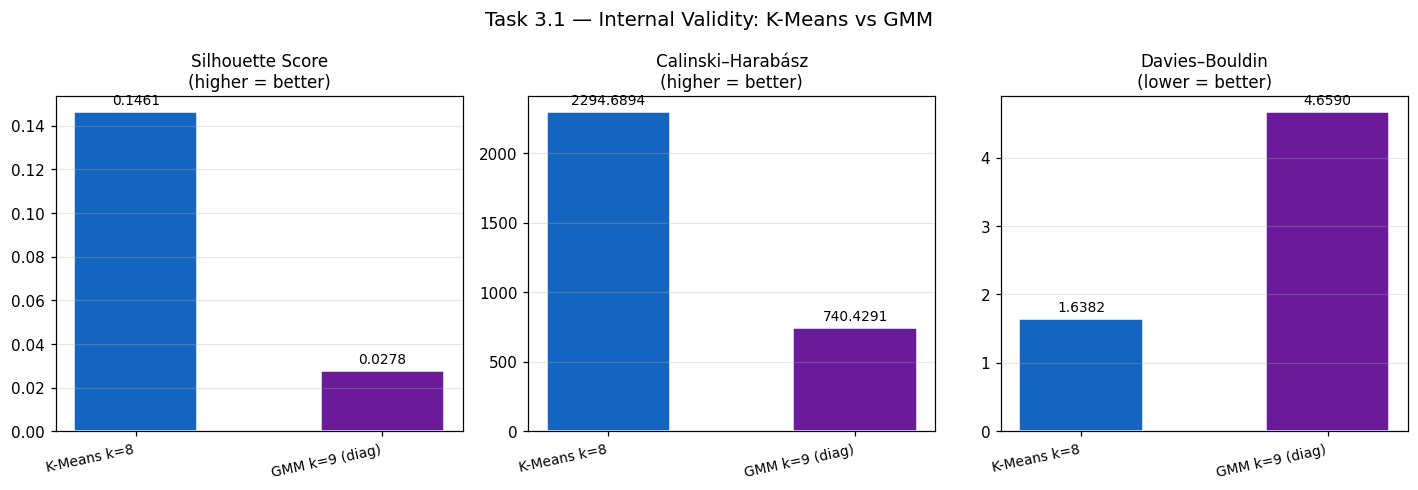

Saved: figures/internal_validity_comparison.png


In [5]:
metrics  = ['silhouette', 'calinski_harabasz', 'davies_bouldin']
titles   = ['Silhouette Score\n(higher = better)',
            'Calinski–Harabász\n(higher = better)',
            'Davies–Bouldin\n(lower = better)']
colours  = ['#1565C0', '#6A1B9A']
labels   = comparison.index.tolist()
x        = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, metric, title in zip(axes, metrics, titles):
    vals = comparison[metric].values
    bars = ax.bar(x, vals, color=colours, width=0.5, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=12, ha='right')
    ax.set_title(title, fontsize=11)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Task 3.1 — Internal Validity: K-Means vs GMM', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'internal_validity_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: figures/internal_validity_comparison.png')

## 3. Task 3.3 — Stability & Sensitivity

### 3.3.1 Seed stability (5 seeds)

In [6]:
print(f'GMM seed stability: k={GMM_BEST_K}, {len(GMM_SEEDS)} seeds ...')
seed_rows  = []
seed_labels = {}

for seed in GMM_SEEDS:
    t0 = time.perf_counter()
    gmm_s = GaussianMixture(
        n_components=GMM_BEST_K, covariance_type=GMM_COV_TYPE,
        n_init=GMM_N_INIT, max_iter=GMM_MAX_ITER,
        random_state=seed, reg_covar=GMM_REG_COVAR,
    )
    gmm_s.fit(X_prepared)
    lbl_full = gmm_s.predict(X_prepared)
    seed_labels[seed] = lbl_full
    elapsed  = time.perf_counter() - t0
    lbl_eval = lbl_full[sample_idx]
    sil = silhouette_score(X_eval, lbl_eval, metric='euclidean')
    ch  = calinski_harabasz_score(X_eval, lbl_eval)
    db  = davies_bouldin_score(X_eval, lbl_eval)
    mn  = pd.Series(lbl_full).value_counts(normalize=True).min()
    seed_rows.append({'seed': seed, 'silhouette': sil,
                      'calinski_harabasz': ch, 'davies_bouldin': db,
                      'min_cluster_share': mn, 'runtime_sec': elapsed})
    print(f'  seed={seed:4d} | Sil={sil:.4f} | CH={ch:.1f} | DB={db:.4f} | t={elapsed:.1f}s')

seed_df = pd.DataFrame(seed_rows)

# ARI between all seed pairs
ari_rows = []
for sa, sb in combinations(GMM_SEEDS, 2):
    ari_rows.append({'seed_a': sa, 'seed_b': sb,
                     'ari': adjusted_rand_score(seed_labels[sa], seed_labels[sb])})
ari_df = pd.DataFrame(ari_rows)

stability_summary = pd.DataFrame([{
    'method'                : f'GMM k={GMM_BEST_K} ({GMM_COV_TYPE})',
    'n_seeds'               : len(GMM_SEEDS),
    'silhouette_mean'       : seed_df['silhouette'].mean(),
    'silhouette_std'        : seed_df['silhouette'].std(),
    'ch_mean'               : seed_df['calinski_harabasz'].mean(),
    'ch_std'                : seed_df['calinski_harabasz'].std(),
    'db_mean'               : seed_df['davies_bouldin'].mean(),
    'db_std'                : seed_df['davies_bouldin'].std(),
    'ari_between_runs_mean' : ari_df['ari'].mean(),
    'ari_between_runs_std'  : ari_df['ari'].std(),
    'ari_between_runs_min'  : ari_df['ari'].min(),
}])

seed_df.to_csv(TABLES_DIR / 'gmm_seed_stability.csv', index=False)
ari_df.to_csv(TABLES_DIR / 'gmm_ari_between_seeds.csv', index=False)
stability_summary.to_csv(TABLES_DIR / 'gmm_stability_summary.csv', index=False)

display(stability_summary.round(4))
print(f'Silhouette: {seed_df["silhouette"].mean():.4f} ± {seed_df["silhouette"].std():.4f}')
print(f'ARI between runs: {ari_df["ari"].mean():.4f} ± {ari_df["ari"].std():.4f}')

GMM seed stability: k=9, 5 seeds ...
  seed=   7 | Sil=0.0478 | CH=958.7 | DB=2.7993 | t=2.1s
  seed=  21 | Sil=0.0514 | CH=851.5 | DB=3.4819 | t=1.8s
  seed=  42 | Sil=0.0278 | CH=740.4 | DB=4.6590 | t=2.0s
  seed=  84 | Sil=0.0518 | CH=899.3 | DB=3.3870 | t=2.9s
  seed= 123 | Sil=0.0237 | CH=818.2 | DB=3.6032 | t=2.0s


,method,n_seeds,silhouette_mean,silhouette_std,ch_mean,ch_std,db_mean,db_std,ari_between_runs_mean,ari_between_runs_std,ari_between_runs_min
0,GMM k=9 (diag),5,0.0405,0.0137,853.6253,82.4635,3.5861,0.6747,0.6303,0.1722,0.437


Silhouette: 0.0405 ± 0.0137
ARI between runs: 0.6303 ± 0.1722


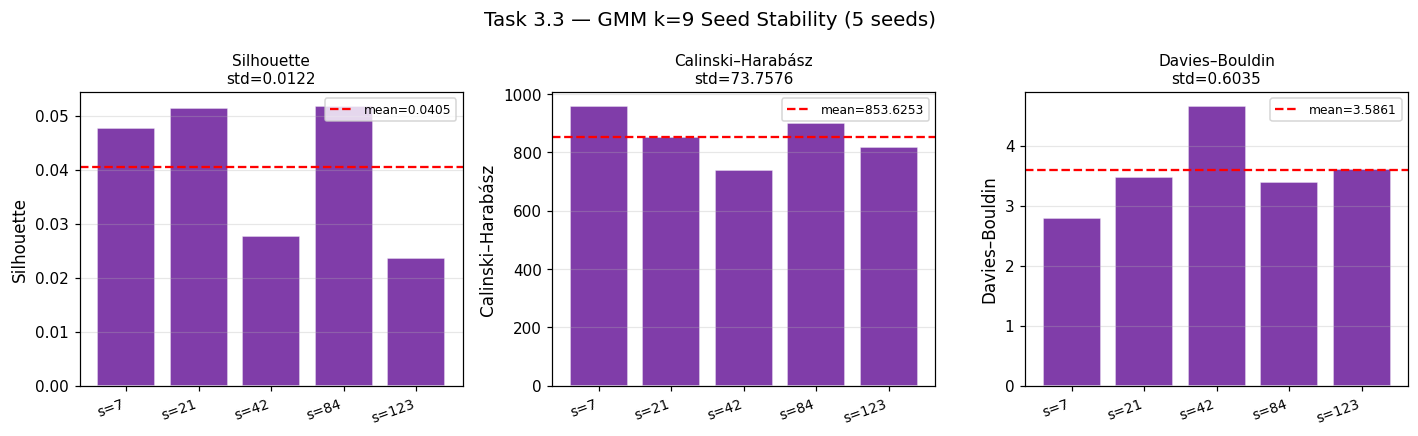

Saved: figures/gmm_seed_stability.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label) in zip(axes, [
    ('silhouette', 'Silhouette'),
    ('calinski_harabasz', 'Calinski–Harabász'),
    ('davies_bouldin', 'Davies–Bouldin')
]):
    vals = seed_df[col].values
    ax.bar(range(len(GMM_SEEDS)), vals, color='#6A1B9A', edgecolor='white', alpha=0.85)
    ax.axhline(vals.mean(), ls='--', color='red', lw=1.5, label=f'mean={vals.mean():.4f}')
    ax.set_xticks(range(len(GMM_SEEDS)))
    ax.set_xticklabels([f's={s}' for s in GMM_SEEDS], rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{label}\nstd={vals.std():.4f}', fontsize=10)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Task 3.3 — GMM k={GMM_BEST_K} Seed Stability ({len(GMM_SEEDS)} seeds)', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'gmm_seed_stability.png', bbox_inches='tight')
plt.show()
print('Saved: figures/gmm_seed_stability.png')

### 3.3.2 Preprocessing variant: StandardScaler vs RobustScaler

In [8]:
# Try to load pre-saved robust matrix; if not found, rebuild from raw data
_rob_candidates = [
    TABLES_DIR / 'robust_final_precluster_matrix.csv',
    TABLES_DIR / 'robust_precluster_matrix.csv',
]
_rob_path = next((p for p in _rob_candidates if p.exists()), None)

if _rob_path is not None:
    print(f'Loading robust matrix from: {_rob_path.name}')
    X_robust = pd.read_csv(_rob_path).values
    print(f'  Shape: {X_robust.shape}')
else:
    print('Robust matrix not found — rebuilding from raw data...')
    _csv = 'hotel_bookings_course_release_v1.csv'
    _csv_candidates = [TABLES_DIR / _csv, TABLES_DIR.parent / _csv, Path('.') / _csv]
    DATA_PATH = next((p for p in _csv_candidates if p.exists()), None)
    if DATA_PATH is None:
        raise FileNotFoundError(f'{_csv!r} not found — needed for RobustScaler sensitivity.')

    df_raw = pd.read_csv(DATA_PATH)

    # Feature engineering (identical to project.ipynb)
    month_to_season = {
        'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
        'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
        'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
        'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    }
    def group_country(code):
        if pd.isna(code): return 'Other'
        if code == 'PRT': return 'Portugal'
        if code == 'ESP': return 'Spain'
        if code in {'GBR', 'IRL'}: return 'British Isles'
        if code in {'FRA', 'BEL', 'NLD', 'LUX'}: return 'Western Europe'
        if code in {'DEU', 'AUT', 'CHE'}: return 'DACH'
        if code in {'ITA', 'GRC', 'MLT', 'CYP'}: return 'Southern Europe'
        if code in {'SWE', 'NOR', 'DNK', 'FIN', 'ISL'}: return 'Nordics'
        if code in {'POL','ROU','RUS','UKR','CZE','SVK','HUN','BGR',
                    'SRB','HRV','SVN','EST','LVA','LTU','BLR'}: return 'Eastern Europe'
        if code in {'BRA','ARG','CHL','COL','MEX','PER','URY','VEN',
                    'ECU','BOL','PRY','DOM','CUB','PAN','CRI','GTM',
                    'HND','SLV','NIC','JAM','TTO'}: return 'Latin America'
        if code in {'CHN','CN','JPN','KOR','IND','THA','MYS','SGP',
                    'IDN','VNM','PHL','TWN','HKG','MAC'}: return 'Asia'
        return 'Other'

    _rare_room = {'G','B','C','H','P','L'}
    _rare_dist  = {'GDS','Undefined'}
    _rare_mkt   = {'Undefined','Aviation','Complementary'}

    raw_clustering_features = [
        'hotel', 'lead_time', 'arrival_date_month',
        'stays_in_weekend_nights', 'stays_in_week_nights',
        'adults', 'children', 'babies', 'country',
        'market_segment', 'distribution_channel',
        'is_repeated_guest', 'previous_cancellations',
        'previous_bookings_not_canceled', 'reserved_room_type',
        'deposit_type', 'customer_type',
        'required_car_parking_spaces', 'total_of_special_requests',
    ]
    X_raw = df_raw[raw_clustering_features].copy()
    X_eng = X_raw.assign(
        arrival_season       = X_raw['arrival_date_month'].map(month_to_season),
        country_group        = X_raw['country'].apply(group_country),
        distribution_channel = X_raw['distribution_channel'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_dist else str(v)),
        market_segment       = X_raw['market_segment'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_mkt else str(v)),
        reserved_room_type   = X_raw['reserved_room_type'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_room else str(v)),
        previous_cancellations         = X_raw['previous_cancellations'].clip(upper=5),
        previous_bookings_not_canceled = X_raw['previous_bookings_not_canceled'].clip(upper=5),
        adults      = X_raw['adults'].clip(upper=4),
        minor_count = (X_raw['children'].fillna(0) + X_raw['babies'].fillna(0)).clip(upper=4),
        total_nights = (X_raw['stays_in_weekend_nights'].fillna(0)
                        + X_raw['stays_in_week_nights'].fillna(0)).clip(upper=20),
    )
    valid_mask = ((X_eng['distribution_channel'] != 'Other') &
                  (X_eng['customer_type'] != 'Other'))
    X_eng = X_eng.loc[valid_mask].reset_index(drop=True)
    _drop = ['arrival_date_month','country','children','babies',
             'stays_in_weekend_nights','stays_in_week_nights']
    X = X_eng.drop(columns=_drop)
    num_features = X.select_dtypes(include='number').columns.tolist()
    cat_features = X.select_dtypes(exclude='number').columns.tolist()
    skewed_num  = ['lead_time']
    regular_num = [c for c in num_features if c not in skewed_num]

    def build_preprocessor(scaler_cls=StandardScaler):
        return ColumnTransformer(transformers=[
            ('num_regular', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', scaler_cls())]), regular_num),
            ('num_skewed',  Pipeline([('imp', SimpleImputer(strategy='median')),
                                      ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                                      ('scale', scaler_cls())]), skewed_num),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                               ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False))]), cat_features),
        ], remainder='drop')

    t0 = time.perf_counter()
    X_robust = build_preprocessor(RobustScaler).fit_transform(X)
    print(f'  RobustScaler matrix built in {time.perf_counter()-t0:.1f}s  shape={X_robust.shape}')

X_eval_rob = X_robust[sample_idx]
print('RobustScaler matrix ready.')

Robust matrix not found — rebuilding from raw data...


FileNotFoundError: 'hotel_bookings_course_release_v1.csv' not found — needed for RobustScaler sensitivity.

In [ ]:
print(f'GMM RobustScaler sensitivity: k={GMM_BEST_K} ...')
t0 = time.perf_counter()
gmm_rob = GaussianMixture(
    n_components=GMM_BEST_K, covariance_type=GMM_COV_TYPE,
    n_init=GMM_N_INIT, max_iter=GMM_MAX_ITER,
    random_state=EVAL_SEED, reg_covar=GMM_REG_COVAR,
)
gmm_rob.fit(X_robust)
gmm_rob_labels = gmm_rob.predict(X_robust)

gmm_rob_sil    = silhouette_score(X_eval_rob, gmm_rob_labels[sample_idx], metric='euclidean')
ari_std_vs_rob = adjusted_rand_score(gmm_labels, gmm_rob_labels)

repr_sensitivity = pd.DataFrame([{
    'method'                : f'GMM k={GMM_BEST_K} ({GMM_COV_TYPE})',
    'repr_std_silhouette'   : gmm_sil,
    'repr_robust_silhouette': gmm_rob_sil,
    'ari_standard_vs_robust': ari_std_vs_rob,
    'runtime_sec'           : time.perf_counter() - t0,
}])
repr_sensitivity.to_csv(TABLES_DIR / 'gmm_repr_sensitivity.csv', index=False)

print(f'  StandardScaler Silhouette : {gmm_sil:.4f}')
print(f'  RobustScaler   Silhouette : {gmm_rob_sil:.4f}')
print(f'  ARI (std vs robust)       : {ari_std_vs_rob:.4f}')
display(repr_sensitivity.round(4))
print('Saved: tables/gmm_repr_sensitivity.csv')

GMM RobustScaler sensitivity: k=8 ...
  StandardScaler Silhouette : 0.0358
  RobustScaler   Silhouette : 0.0687
  ARI (std vs robust)       : 0.4568


,method,repr_std_silhouette,repr_robust_silhouette,ari_standard_vs_robust,runtime_sec
0,GMM k=8 (diag),0.0358,0.0687,0.4568,10.453


Saved: tables/gmm_repr_sensitivity.csv


### 3.3.3 Cross-method ARI: GMM vs K-Means

ARI (KMeans k=8 vs GMM k=8): 0.2247


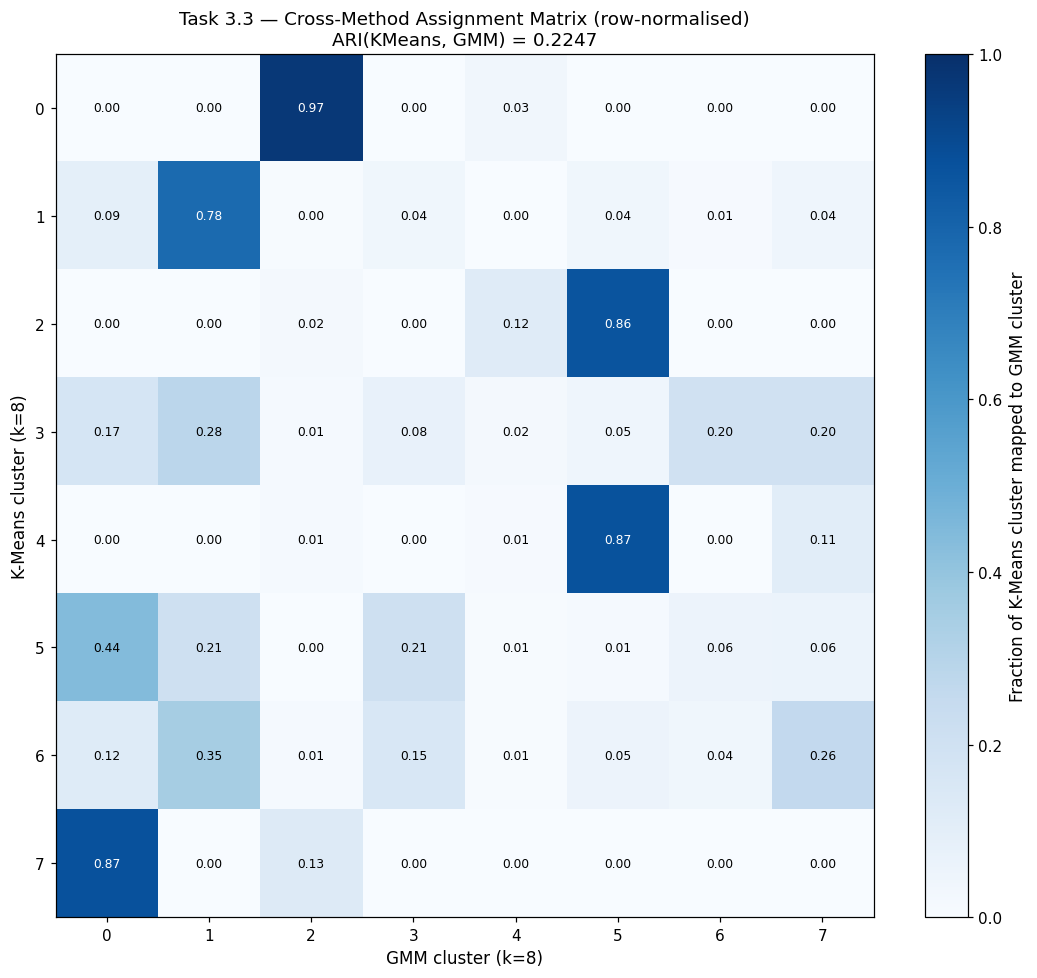

Saved: tables/cross_method_ari.csv  |  figures/cross_method_ari_heatmap.png


In [ ]:
ari_gmm_km = adjusted_rand_score(km_labels, gmm_labels)
print(f'ARI (KMeans k={KMEANS_REF_K} vs GMM k={GMM_BEST_K}): {ari_gmm_km:.4f}')

cross_df = pd.DataFrame([{
    'method_a': f'K-Means k={KMEANS_REF_K}',
    'method_b': f'GMM k={GMM_BEST_K} ({GMM_COV_TYPE})',
    'ari'     : ari_gmm_km,
}])
cross_df.to_csv(TABLES_DIR / 'cross_method_ari.csv', index=False)

conf = confusion_matrix(km_labels, gmm_labels)
conf_norm = conf / conf.sum(axis=1, keepdims=True)
n_km, n_gmm = conf_norm.shape

fig, ax = plt.subplots(figsize=(max(7, n_gmm + 2), max(5, n_km + 1)))
im = ax.imshow(conf_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel(f'GMM cluster (k={GMM_BEST_K})')
ax.set_ylabel(f'K-Means cluster (k={KMEANS_REF_K})')
ax.set_title(f'Task 3.3 — Cross-Method Assignment Matrix (row-normalised)\nARI(KMeans, GMM) = {ari_gmm_km:.4f}')
ax.set_xticks(range(n_gmm))
ax.set_yticks(range(n_km))
plt.colorbar(im, ax=ax, label='Fraction of K-Means cluster mapped to GMM cluster')
for i in range(n_km):
    for j in range(n_gmm):
        ax.text(j, i, f'{conf_norm[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if conf_norm[i,j] > 0.6 else 'black')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cross_method_ari_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: tables/cross_method_ari.csv  |  figures/cross_method_ari_heatmap.png')

## 4. Task 3.4 — Cluster Interpretation & Communication

Profiles built on:
1. **Numerical statistics** — mean of each numeric feature per cluster
2. **Categorical mode** — most frequent category per cluster
3. **Post-hoc variables** — `adr`, `is_canceled`, `meal` (not used in clustering)
4. **Soft membership** — mean max-probability per cluster (cluster cohesion)

In [ ]:
# Load raw data for interpretable profiling
_csv = 'hotel_bookings_course_release_v1.csv'
_csv_candidates = [TABLES_DIR / _csv, TABLES_DIR.parent / _csv, Path('.') / _csv]
DATA_PATH = next((p for p in _csv_candidates if p.exists()), None)

if DATA_PATH is None:
    print('WARNING: raw CSV not found — profiling on preprocessed feature indices only.')
    _profile_on_raw = False
else:
    _profile_on_raw = True
    df_raw = pd.read_csv(DATA_PATH)

    month_to_season = {
        'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
        'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
        'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
        'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    }
    def group_country(code):
        if pd.isna(code): return 'Other'
        if code == 'PRT': return 'Portugal'
        if code == 'ESP': return 'Spain'
        if code in {'GBR', 'IRL'}: return 'British Isles'
        if code in {'FRA', 'BEL', 'NLD', 'LUX'}: return 'Western Europe'
        if code in {'DEU', 'AUT', 'CHE'}: return 'DACH'
        if code in {'ITA', 'GRC', 'MLT', 'CYP'}: return 'Southern Europe'
        if code in {'SWE', 'NOR', 'DNK', 'FIN', 'ISL'}: return 'Nordics'
        if code in {'POL','ROU','RUS','UKR','CZE','SVK','HUN','BGR',
                    'SRB','HRV','SVN','EST','LVA','LTU','BLR'}: return 'Eastern Europe'
        if code in {'BRA','ARG','CHL','COL','MEX','PER','URY','VEN',
                    'ECU','BOL','PRY','DOM','CUB','PAN','CRI','GTM',
                    'HND','SLV','NIC','JAM','TTO'}: return 'Latin America'
        if code in {'CHN','CN','JPN','KOR','IND','THA','MYS','SGP',
                    'IDN','VNM','PHL','TWN','HKG','MAC'}: return 'Asia'
        return 'Other'

    _rare_room = {'G','B','C','H','P','L'}
    _rare_dist  = {'GDS','Undefined'}
    _rare_mkt   = {'Undefined','Aviation','Complementary'}

    raw_clustering_features = [
        'hotel', 'lead_time', 'arrival_date_month',
        'stays_in_weekend_nights', 'stays_in_week_nights',
        'adults', 'children', 'babies', 'country',
        'market_segment', 'distribution_channel',
        'is_repeated_guest', 'previous_cancellations',
        'previous_bookings_not_canceled', 'reserved_room_type',
        'deposit_type', 'customer_type',
        'required_car_parking_spaces', 'total_of_special_requests',
    ]
    X_raw = df_raw[raw_clustering_features].copy()
    X_eng = X_raw.assign(
        arrival_season       = X_raw['arrival_date_month'].map(month_to_season),
        country_group        = X_raw['country'].apply(group_country),
        distribution_channel = X_raw['distribution_channel'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_dist else str(v)),
        market_segment       = X_raw['market_segment'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_mkt else str(v)),
        reserved_room_type   = X_raw['reserved_room_type'].apply(
            lambda v: 'Other' if pd.isna(v) or str(v) in _rare_room else str(v)),
        previous_cancellations         = X_raw['previous_cancellations'].clip(upper=5),
        previous_bookings_not_canceled = X_raw['previous_bookings_not_canceled'].clip(upper=5),
        adults       = X_raw['adults'].clip(upper=4),
        minor_count  = (X_raw['children'].fillna(0) + X_raw['babies'].fillna(0)).clip(upper=4),
        total_nights = (X_raw['stays_in_weekend_nights'].fillna(0)
                        + X_raw['stays_in_week_nights'].fillna(0)).clip(upper=20),
    )
    valid_mask = ((X_eng['distribution_channel'] != 'Other') &
                  (X_eng['customer_type'] != 'Other'))
    df_full = df_raw.loc[valid_mask].reset_index(drop=True)
    X_eng   = X_eng.loc[valid_mask].reset_index(drop=True)
    _drop = ['arrival_date_month','country','children','babies',
             'stays_in_weekend_nights','stays_in_week_nights']
    X = X_eng.drop(columns=_drop)
    num_features = X.select_dtypes(include='number').columns.tolist()
    cat_features = X.select_dtypes(exclude='number').columns.tolist()

    print(f'Raw data loaded: {df_full.shape}')

Raw data loaded: (119192, 32)


In [ ]:
if _profile_on_raw:
    profile_df = X.copy()
    profile_df['cluster']  = gmm_labels
    profile_df['max_prob'] = gmm_proba.max(axis=1)

    gmm_cluster_share = (gmm_share * 100).round(2).rename('cluster_share_pct').to_frame()

    # Numerical means
    gmm_num_profile = profile_df.groupby('cluster')[num_features].mean().round(2)
    display(gmm_num_profile)

    # Categorical mode + pct
    gmm_cat_rows = []
    for c in cat_features:
        top     = profile_df.groupby('cluster')[c].agg(lambda s: s.value_counts(normalize=True).index[0])
        top_pct = profile_df.groupby('cluster')[c].agg(lambda s: round(100*s.value_counts(normalize=True).iloc[0],2))
        for cl in top.index:
            gmm_cat_rows.append({'cluster': int(cl), 'feature': c,
                                  'top_category': top.loc[cl], 'top_category_pct': top_pct.loc[cl]})
    gmm_cat_profile = pd.DataFrame(gmm_cat_rows).sort_values(['cluster','feature']).reset_index(drop=True)

    # Post-hoc (outcome variables)
    posthoc_only = ['meal', 'adr', 'is_canceled', 'reservation_status']
    posthoc_only = [c for c in posthoc_only if c in df_full.columns]
    posthoc_df = df_full[posthoc_only].copy()
    posthoc_df['cluster'] = gmm_labels

    gmm_posthoc = posthoc_df.groupby('cluster').agg(
        adr_mean              = ('adr', 'mean'),
        adr_median            = ('adr', 'median'),
        cancellation_rate_pct = ('is_canceled', lambda s: round(100*s.mean(),2)),
    ).round(2) if 'adr' in posthoc_only else pd.DataFrame()

    if 'meal' in posthoc_only:
        meal_top = posthoc_df.groupby('cluster')['meal'].agg(
            lambda s: s.value_counts(normalize=True).index[0]).rename('top_meal')
        meal_pct = posthoc_df.groupby('cluster')['meal'].agg(
            lambda s: round(100*s.value_counts(normalize=True).iloc[0],2)).rename('top_meal_pct')
    else:
        meal_top = meal_pct = pd.Series(dtype=float)

    gmm_prob_profile = profile_df.groupby('cluster')['max_prob'].mean().round(4)

    _dominant_cats = ['hotel','market_segment','distribution_channel',
                      'deposit_type','customer_type','arrival_season','country_group']
    _dominant_cats = [f for f in _dominant_cats if f in cat_features]
    gmm_summary = (gmm_cluster_share
                   .join(gmm_num_profile)
                   .join(gmm_posthoc if len(gmm_posthoc) else pd.DataFrame())
                   .join(pd.concat([meal_top, meal_pct], axis=1) if len(meal_top) else pd.DataFrame())
                   .join(gmm_prob_profile.rename('mean_max_membership_prob')))

    for feat in _dominant_cats:
        slc = (gmm_cat_profile[gmm_cat_profile['feature'] == feat]
               .set_index('cluster')[['top_category','top_category_pct']]
               .rename(columns={'top_category': f'{feat}_top', 'top_category_pct': f'{feat}_top_pct'}))
        gmm_summary = gmm_summary.join(slc)

    gmm_num_profile.to_csv(TABLES_DIR / 'gmm_cluster_numeric_profile.csv')
    gmm_cat_profile.to_csv(TABLES_DIR / 'gmm_cluster_categorical_profile.csv', index=False)
    if len(gmm_posthoc): gmm_posthoc.to_csv(TABLES_DIR / 'gmm_cluster_posthoc_profile.csv')
    gmm_summary.to_csv(TABLES_DIR / 'gmm_cluster_summary.csv')
    display(gmm_summary)
    print('Saved: gmm_cluster_numeric_profile, gmm_cluster_categorical_profile, gmm_cluster_summary')
else:
    print('Raw data not available — profile tables skipped.')

,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights
cluster,,,,,,,,,
0,159.20,1.80,0.00,0.18,0.00,0.00,0.23,0.00,2.89
1,86.38,1.98,0.00,0.00,0.00,0.00,0.89,0.00,3.62
2,50.55,1.51,0.71,0.50,1.49,0.14,0.61,0.06,2.38
3,132.17,1.83,0.00,0.00,0.00,0.00,0.33,0.00,3.69
4,76.73,1.58,0.00,0.00,0.73,0.45,0.45,0.09,2.98
5,75.36,1.98,0.00,0.00,0.00,0.38,0.85,0.75,3.69
6,59.28,1.49,0.00,0.00,0.00,0.00,0.14,0.00,2.72
7,90.46,1.84,0.00,0.00,0.00,0.00,0.47,0.10,4.36


,cluster_share_pct,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights,...,distribution_channel_top,distribution_channel_top_pct,deposit_type_top,deposit_type_top_pct,customer_type_top,customer_type_top_pct,arrival_season_top,arrival_season_top_pct,country_group_top,country_group_top_pct
0,23.86,159.20,1.80,0.00,0.18,0.00,0.00,0.23,0.00,2.89,...,TA/TO,100.00,No Deposit,53.88,Transient,66.65,Autumn,29.46,Portugal,100.00
1,31.97,86.38,1.98,0.00,0.00,0.00,0.00,0.89,0.00,3.62,...,TA/TO,100.00,No Deposit,100.00,Transient,92.25,Summer,34.31,Western Europe,21.06
2,4.51,50.55,1.51,0.71,0.50,1.49,0.14,0.61,0.06,2.38,...,TA/TO,38.84,No Deposit,93.40,Transient,71.59,Autumn,28.75,Portugal,76.94
3,10.26,132.17,1.83,0.00,0.00,0.00,0.00,0.33,0.00,3.69,...,TA/TO,100.00,No Deposit,100.00,Transient-Party,58.77,Autumn,29.02,DACH,25.00
4,1.45,76.73,1.58,0.00,0.00,0.73,0.45,0.45,0.09,2.98,...,Corporate,44.20,No Deposit,91.42,Transient,46.46,Autumn,35.21,Portugal,42.46
5,13.03,75.36,1.98,0.00,0.00,0.00,0.38,0.85,0.75,3.69,...,TA/TO,74.48,No Deposit,100.00,Transient,91.22,Summer,42.38,Portugal,28.02
6,5.51,59.28,1.49,0.00,0.00,0.00,0.00,0.14,0.00,2.72,...,Corporate,60.09,No Deposit,82.77,Transient,62.50,Autumn,32.09,Portugal,53.16
7,9.41,90.46,1.84,0.00,0.00,0.00,0.00,0.47,0.10,4.36,...,Direct,63.19,No Deposit,100.00,Transient,65.50,Summer,34.52,Portugal,44.64


Saved: gmm_cluster_numeric_profile, gmm_cluster_categorical_profile, gmm_cluster_summary


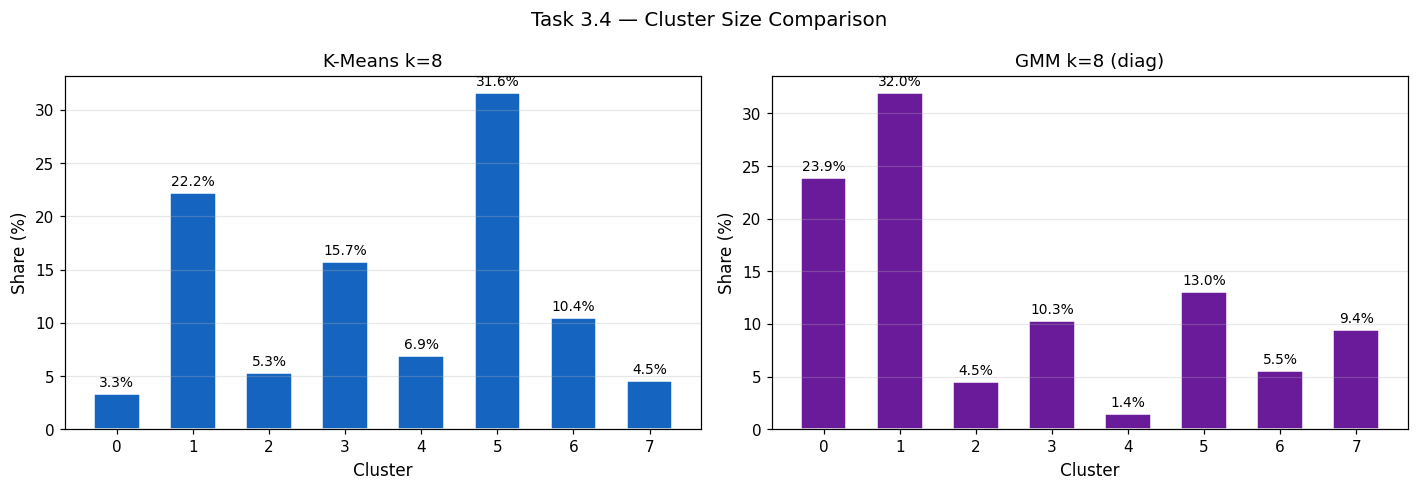

Saved: figures/cluster_share_comparison.png


In [ ]:
# ── Cluster share comparison figure ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (shares, title, colour) in zip(axes, [
    (km_share * 100,                          f'K-Means k={KMEANS_REF_K}',            '#1565C0'),
    (gmm_share * 100,                         f'GMM k={GMM_BEST_K} ({GMM_COV_TYPE})', '#6A1B9A'),
]):
    bars = ax.bar(shares.index, shares.values, color=colour, edgecolor='white', width=0.6)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Share (%)')
    ax.set_title(title)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(shares.index)

fig.suptitle('Task 3.4 — Cluster Size Comparison', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cluster_share_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: figures/cluster_share_comparison.png')

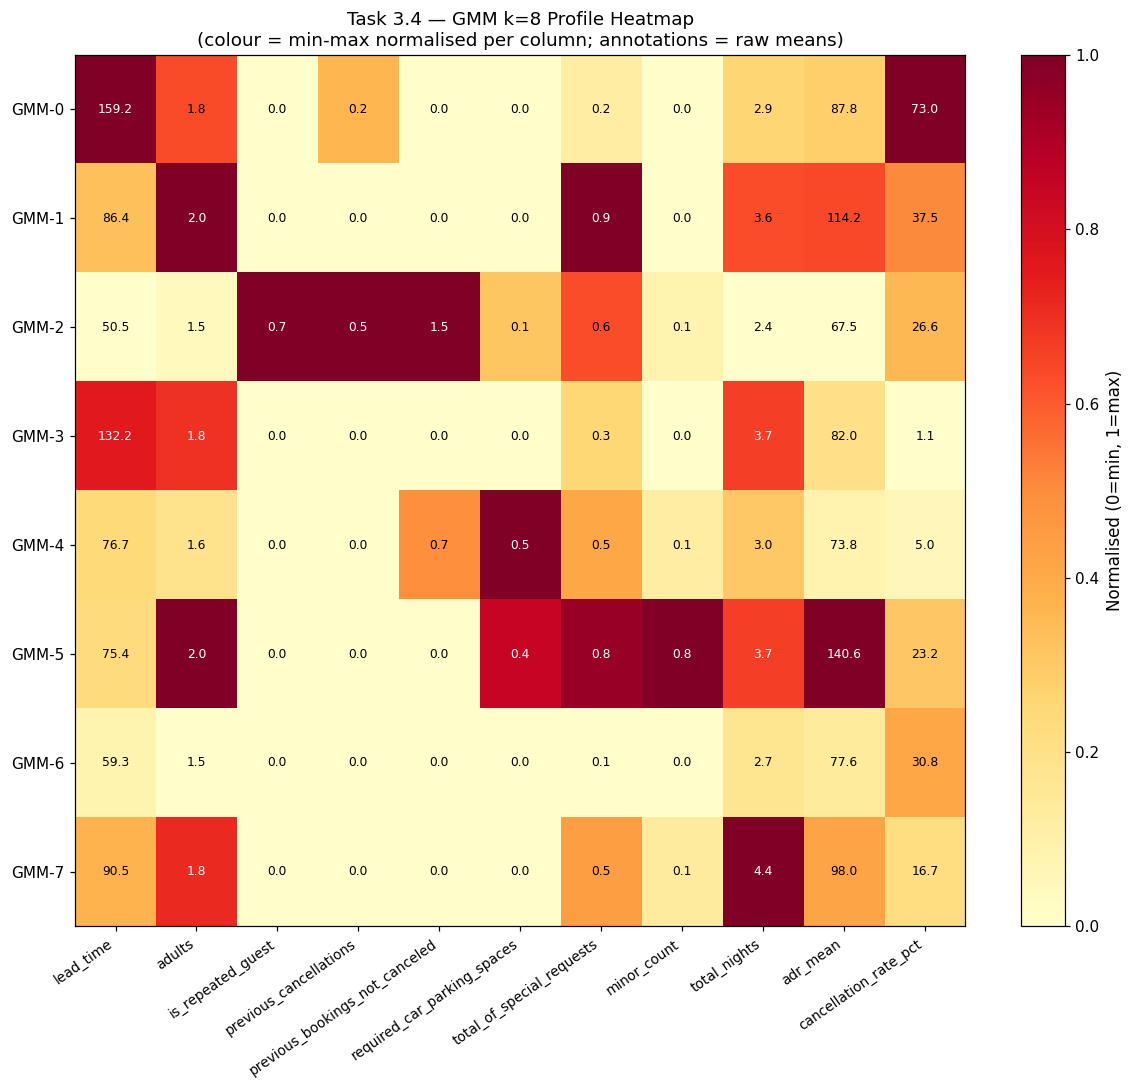

Saved: figures/gmm_cluster_profile_heatmap.png


In [ ]:
# ── Profile heatmap ────────────────────────────────────────────────────────
if _profile_on_raw:
    hm_features = num_features + (['adr_mean', 'cancellation_rate_pct']
                                   if len(gmm_posthoc) else [])
    hm_data = gmm_summary[[f for f in hm_features if f in gmm_summary.columns]].astype(float)
    hm_norm = pd.DataFrame(MinMaxScaler().fit_transform(hm_data),
                            index=hm_data.index, columns=hm_data.columns)

    fig, ax = plt.subplots(figsize=(max(10, len(hm_data.columns)), GMM_BEST_K + 2))
    im = ax.imshow(hm_norm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(hm_data.columns)))
    ax.set_xticklabels(hm_data.columns, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(GMM_BEST_K))
    ax.set_yticklabels([f'GMM-{i}' for i in range(GMM_BEST_K)], fontsize=10)
    ax.set_title(f'Task 3.4 — GMM k={GMM_BEST_K} Profile Heatmap\n'
                 '(colour = min-max normalised per column; annotations = raw means)')
    plt.colorbar(im, ax=ax, label='Normalised (0=min, 1=max)')
    for i in range(GMM_BEST_K):
        for j, feat in enumerate(hm_data.columns):
            ax.text(j, i, f'{hm_data.iloc[i][feat]:.1f}', ha='center', va='center', fontsize=8,
                    color='white' if hm_norm.values[i,j] > 0.65 else 'black')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'gmm_cluster_profile_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: figures/gmm_cluster_profile_heatmap.png')

Mean max-membership probability per cluster:
0    1.0000
1    1.0000
2    1.0000
3    0.9999
4    0.9978
5    0.9990
6    0.9976
7    0.9999


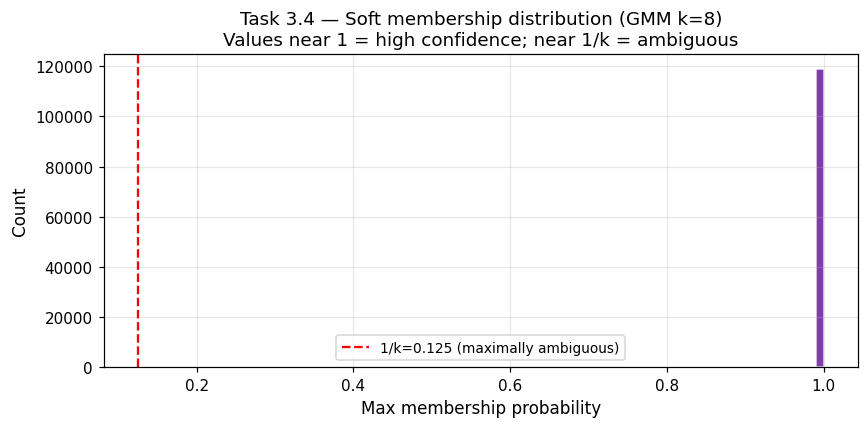

Saved: figures/gmm_membership_distribution.png


In [ ]:
# ── Soft membership distribution ───────────────────────────────────────────
print('Mean max-membership probability per cluster:')
print(pd.Series(gmm_proba.max(axis=1)).groupby(gmm_labels).mean().round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gmm_proba.max(axis=1), bins=50, color='#6A1B9A', edgecolor='white', alpha=0.85)
ax.set_xlabel('Max membership probability')
ax.set_ylabel('Count')
ax.set_title(f'Task 3.4 — Soft membership distribution (GMM k={GMM_BEST_K})\n'
             'Values near 1 = high confidence; near 1/k = ambiguous')
ax.axvline(1/GMM_BEST_K, ls='--', color='red', lw=1.5,
           label=f'1/k={1/GMM_BEST_K:.3f} (maximally ambiguous)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'gmm_membership_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: figures/gmm_membership_distribution.png')

## 5. Update experiments.csv (final model row)

In [ ]:
exp_path = TABLES_DIR / 'experiments.csv'
existing = pd.read_csv(exp_path)

# Check if final model row already exists
gmm_final_exists = existing[
    (existing['method'] == 'gmm') &
    (existing['diagnostics'].str.contains('seed_stability', na=False))
]

if len(gmm_final_exists):
    print(f'Final GMM stability row already in experiments.csv — skipping.')
else:
    nums = [int(eid.replace('exp_','')) for eid in existing['run_id']
            if str(eid).startswith('exp_') and str(eid)[4:].isdigit()]
    next_id = max(nums, default=0) + 1

    new_row = pd.DataFrame([{
        'run_id'           : f'exp_{next_id:03d}',
        'representation_id': 'final_precluster_matrix',
        'method'           : 'gmm',
        'parameters'       : (f'n_components={GMM_BEST_K}; covariance_type={GMM_COV_TYPE}; '
                              f'n_init={GMM_N_INIT}; max_iter={GMM_MAX_ITER}; '
                              f'reg_covar={GMM_REG_COVAR}; selected_model=True; selection_rule=bic_minimum'),
        'seed'             : '|'.join(str(s) for s in GMM_SEEDS),
        'sample_rule'      : f'fit=full_dataset_n{X_prepared.shape[0]}; eval_subsample_n{EVAL_N}_seed{EVAL_SEED}',
        'metrics'          : (f'silhouette_mean={seed_df["silhouette"].mean():.6f}; '
                              f'silhouette_std={seed_df["silhouette"].std():.6f}; '
                              f'calinski_harabasz_mean={seed_df["calinski_harabasz"].mean():.4f}; '
                              f'davies_bouldin_mean={seed_df["davies_bouldin"].mean():.6f}; '
                              f'ari_between_runs_mean={ari_df["ari"].mean():.6f}; '
                              f'ari_between_runs_std={ari_df["ari"].std():.6f}; '
                              f'ari_between_runs_min={ari_df["ari"].min():.6f}; '
                              f'ari_std_vs_robust={ari_std_vs_rob:.6f}; '
                              f'ari_gmm_vs_kmeans={ari_gmm_km:.6f}; '
                              f'min_cluster_share={gmm_min_share:.6f}'),
        'diagnostics'      : 'seed_stability_5runs; repr_sensitivity_std_vs_robust; cross_method_ari_vs_kmeans',
        'notes'            : (f'Task 3 final model row; BIC-optimal k={GMM_BEST_K}; '
                              f'{len(GMM_SEEDS)} seeds stability; cross-method ARI vs KMeans k={KMEANS_REF_K}')
    }])

    updated = pd.concat([existing, new_row], ignore_index=True)
    updated.to_csv(exp_path, index=False)
    print(f'experiments.csv: {len(existing)} -> {len(updated)} rows (added exp_{next_id:03d})')

experiments.csv: 20 -> 21 rows (added exp_021)


## Summary

In [ ]:
print('=' * 60)
print('  TASK 3 (3.1 + 3.3 + 3.4) COMPLETE')
print('=' * 60)
print(f'  GMM k          : {GMM_BEST_K}')
print(f'  KMeans k       : {KMEANS_REF_K}')
print()
print('  3.1 Internal validity:')
print(f'    KMeans  Sil={km_sil:.4f} | CH={km_ch:.1f} | DB={km_db:.4f}')
print(f'    GMM     Sil={gmm_sil:.4f} | CH={gmm_ch:.1f} | DB={gmm_db:.4f}')
print()
print(f'  3.3 Seed stability (ARI): {ari_df["ari"].mean():.4f} ± {ari_df["ari"].std():.4f}')
print(f'  3.3 Repr sensitivity (ARI std vs rob): {ari_std_vs_rob:.4f}')
print(f'  3.3 Cross-method ARI (GMM vs KMeans): {ari_gmm_km:.4f}')
print()
print('  Figures:')
for f in ['internal_validity_comparison.png', 'gmm_seed_stability.png',
           'cross_method_ari_heatmap.png', 'cluster_share_comparison.png',
           'gmm_cluster_profile_heatmap.png', 'gmm_membership_distribution.png']:
    p = FIGURES_DIR / f
    print(f'    {"OK" if p.exists() else "MISSING":6s} {f}')
print()
print('  Next: run task4_repository.ipynb')
print('=' * 60)

  TASK 3 (3.1 + 3.3 + 3.4) COMPLETE
  GMM k          : 8
  KMeans k       : 8

  3.1 Internal validity:
    KMeans  Sil=0.1461 | CH=2294.7 | DB=1.6382
    GMM     Sil=0.0358 | CH=911.7 | DB=3.0756

  3.3 Seed stability (ARI): 0.6240 ± 0.1266
  3.3 Repr sensitivity (ARI std vs rob): 0.4568
  3.3 Cross-method ARI (GMM vs KMeans): 0.2247

  Figures:
    OK     internal_validity_comparison.png
    OK     gmm_seed_stability.png
    OK     cross_method_ari_heatmap.png
    OK     cluster_share_comparison.png
    OK     gmm_cluster_profile_heatmap.png
    OK     gmm_membership_distribution.png

  Next: run task4_repository.ipynb
